In [ ]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
!kaggle datasets download -d computingvictor/transactions-fraud-datasets

Dataset URL: https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets
License(s): apache-2.0
 97% 336M/348M [00:02<00:00, 169MB/s]
100% 348M/348M [00:02<00:00, 156MB/s]


In [ ]:
!unzip transactions-fraud-datasets.zip

Archive:  transactions-fraud-datasets.zip
  inflating: cards_data.csv          
  inflating: mcc_codes.json          
  inflating: train_fraud_labels.json  
  inflating: transactions_data.csv   
  inflating: users_data.csv          


In [ ]:
# prompt: load dataframes of  transactions-fraud-datasets.zip

import pandas as pd

# Assuming the unzipped files are in the current directory
# and the relevant file is 'transactions.csv' (replace if different)

try:
  df_transactions = pd.read_csv('transactions_data.csv')
  print("Transactions DataFrame loaded successfully.")
  print(df_transactions.head()) # Display the first few rows
except FileNotFoundError:
  print("Error: transactions.csv not found. Check the file name and location.")
except pd.errors.ParserError:
    print("Error: Could not parse transactions.csv. Check the file format.")
except Exception as e:
  print(f"An unexpected error occurred: {e}")


Transactions DataFrame loaded successfully.
        id                 date  client_id  card_id   amount  \
0  7475327  2010-01-01 00:01:00       1556     2972  $-77.00   
1  7475328  2010-01-01 00:02:00        561     4575   $14.57   
2  7475329  2010-01-01 00:02:00       1129      102   $80.00   
3  7475331  2010-01-01 00:05:00        430     2860  $200.00   
4  7475332  2010-01-01 00:06:00        848     3915   $46.41   

            use_chip  merchant_id merchant_city merchant_state      zip   mcc  \
0  Swipe Transaction        59935        Beulah             ND  58523.0  5499   
1  Swipe Transaction        67570    Bettendorf             IA  52722.0  5311   
2  Swipe Transaction        27092         Vista             CA  92084.0  4829   
3  Swipe Transaction        27092   Crown Point             IN  46307.0  4829   
4  Swipe Transaction        13051       Harwood             MD  20776.0  5813   

  errors  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


In [ ]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          object 
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             int64  
 11  errors          object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.2+ GB


In [ ]:
#load mcc_codes from json and join on df_transactions

import json
import pandas as pd # Ensure pandas is imported

try:
  with open('mcc_codes.json', 'r') as json_file:
    mcc_codes = json.load(json_file)
    print("MCC codes loaded successfully.")
    # Create DataFrame with MCC codes as index and descriptions as a column
    df_mcc_codes = pd.DataFrame.from_dict(mcc_codes, orient='index', columns=['description'])
    print(df_mcc_codes.head()) # Display the first few rows
    # Reset the index and drop the old index
    df_mcc_codes = df_mcc_codes.reset_index().rename(columns={'index': 'mcc'})
except FileNotFoundError:
  print("Error: mcc_codes.json not found. Check the file name and location.")

#set dtype of column 1 to int64
df_mcc_codes['mcc'] = df_mcc_codes['mcc'].astype('int64')

df_merged = df_transactions.merge(df_mcc_codes, on="mcc", how="left")

MCC codes loaded successfully.
                               description
5812         Eating Places and Restaurants
5541                      Service Stations
7996  Amusement Parks, Carnivals, Circuses
5411          Grocery Stores, Supermarkets
4784                 Tolls and Bridge Fees


In [ ]:
df_merged.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,description
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN,Miscellaneous Food Stores
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN,Department Stores
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,Money Transfer
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN,Money Transfer
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN,Drinking Places (Alcoholic Beverages)


In [ ]:
# Data Cleaning

In [ ]:
df_merged.drop_duplicates(inplace = True)

In [ ]:
# if merchant_city == ONLINE, set merchant_state and zip to None
df_merged.loc[df_merged['merchant_city'] == 'ONLINE', ['merchant_state', 'zip']] = ["N/A", "N/A"]

# fill error with N/A
df_merged['errors'].fillna('N/A', inplace=True)
df_merged['zip'] = df_merged['zip'].fillna('N/A')
df_merged.isnull().sum()


<ipython-input-6-02978c93ad5d>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'N/A' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_merged.loc[df_merged['merchant_city'] == 'ONLINE', ['merchant_state', 'zip']] = ["N/A", "N/A"]
<ipython-input-6-02978c93ad5d>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['errors'].fillna('N/A', inplace=True)


,0
id,0
date,0
client_id,0
card_id,0
amount,0
use_chip,0
merchant_id,0
merchant_city,0
merchant_state,0
zip,0


In [ ]:
# print all rows with naN zip column

df_merged[df_merged['zip'].isna()]

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,description


In [ ]:
df_merged['amount'].head()
# remove dollar sign and convert amount to float
df_merged['amount'] = df_merged['amount'].str.replace('$', '').astype(float)

In [ ]:
df_merged['timestamp'] = pd.to_datetime(df_merged['date'])

In [ ]:
df_merged.drop('date', axis=1, inplace=True)

In [ ]:
df_merged['day_of_week'] = df_merged['timestamp'].dt.day_name()
df_merged['hour'] = df_merged['timestamp'].dt.hour
df_merged['month'] = df_merged['timestamp'].dt.month

In [ ]:
# for testing  plotting
df = df_merged.head(20000)

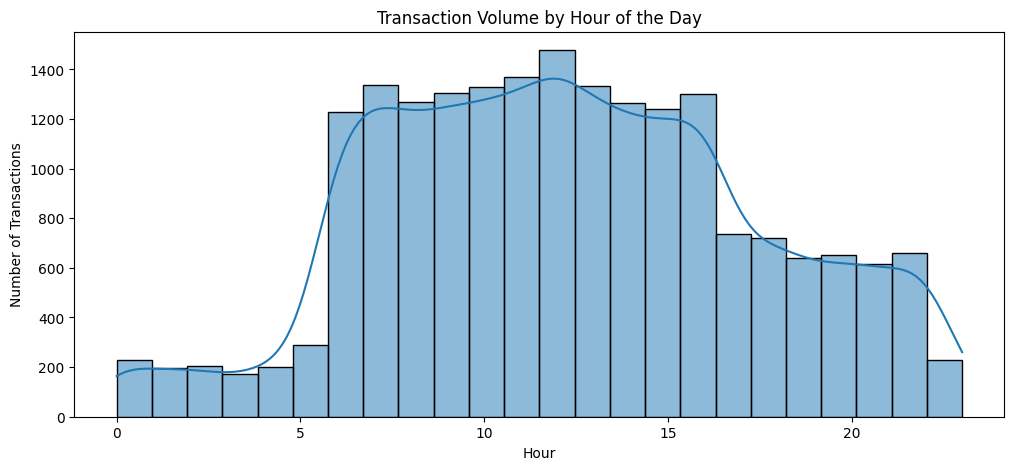

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
sns.histplot(df['hour'], bins=24, kde=True)
plt.title("Transaction Volume by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.show()

<ipython-input-23-c318f42610a3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amount'] = df['amount'].astype(float)  # Convert to numeric if needed


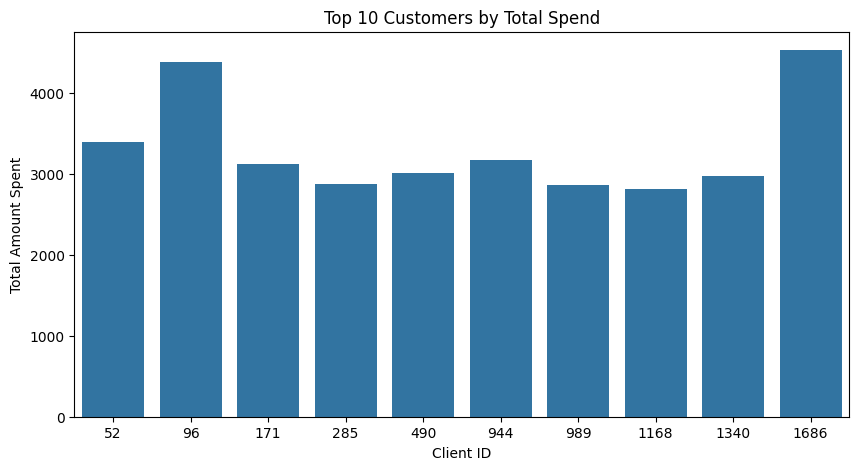

In [ ]:
df['amount'] = df['amount'].astype(float)  # Convert to numeric if needed
top_clients = df.groupby('client_id')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_clients.index, y=top_clients.values)
plt.title("Top 10 Customers by Total Spend")
plt.xlabel("Client ID")
plt.ylabel("Total Amount Spent")
plt.show()

<ipython-input-24-128afff4c26d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amount'] = df['amount'].astype(float)


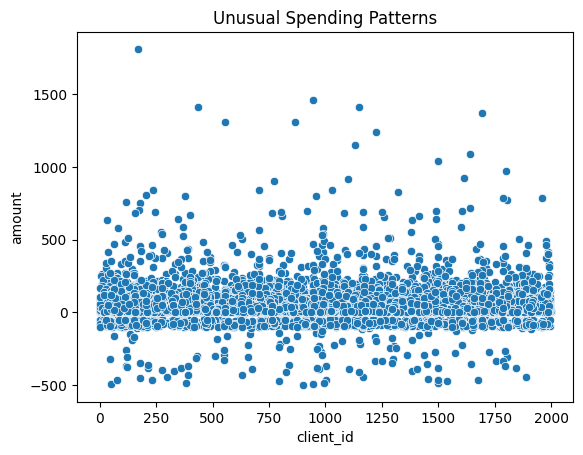

In [ ]:
df['amount'] = df['amount'].astype(float)
sns.scatterplot(x='client_id', y='amount', data=df)
plt.title("Unusual Spending Patterns")
plt.show()

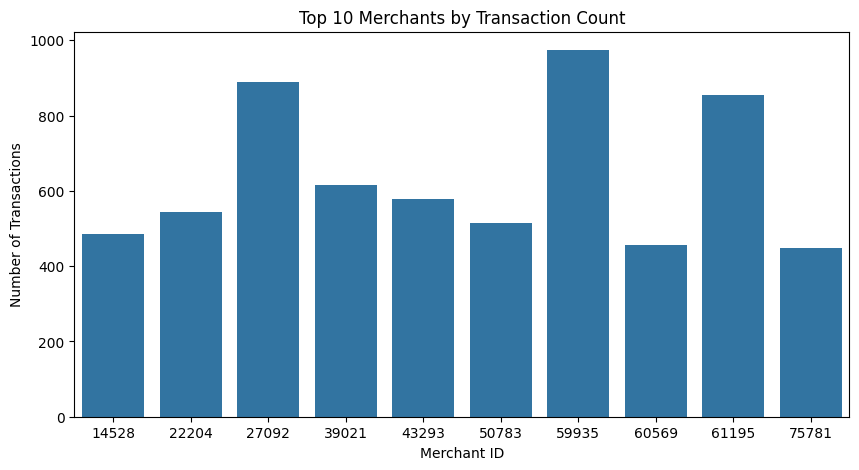

In [ ]:
top_merchants = df['merchant_id'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_merchants.index, y=top_merchants.values)
plt.title("Top 10 Merchants by Transaction Count")
plt.xlabel("Merchant ID")
plt.ylabel("Number of Transactions")
plt.show()

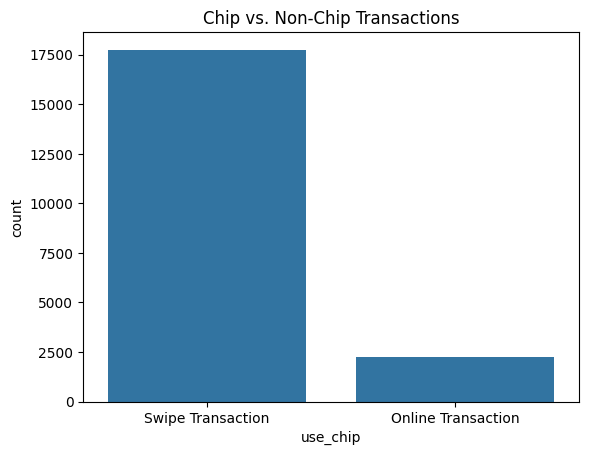

In [ ]:
sns.countplot(x='use_chip', data=df)
plt.title("Chip vs. Non-Chip Transactions")
plt.show()

<ipython-input-27-76341ff2dc33>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_total_spending.index, y=city_total_spending.values, palette="Reds_r")


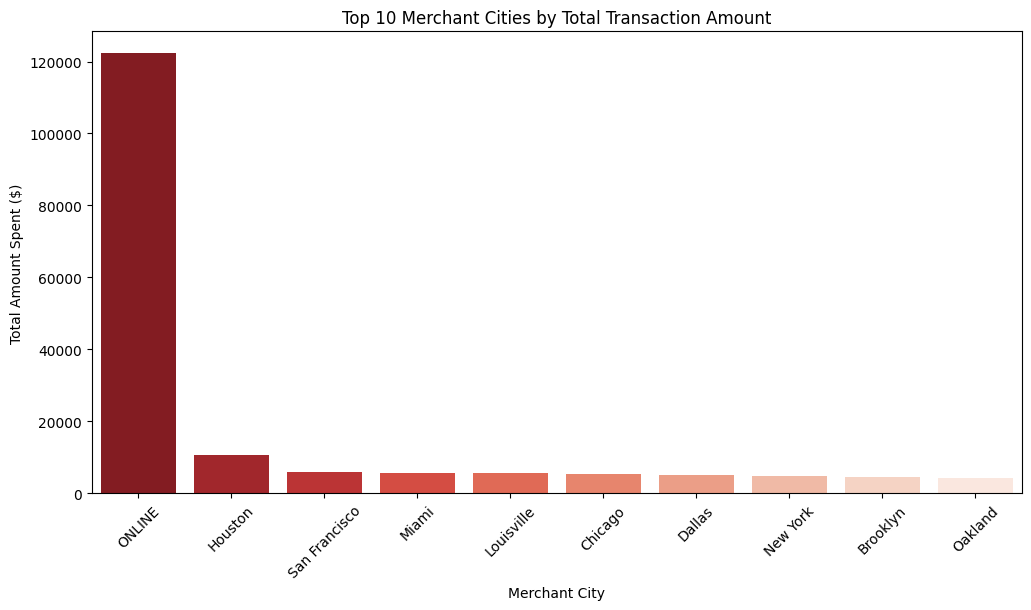

In [ ]:
city_total_spending = df.groupby('merchant_city')['amount'].sum().sort_values(ascending=False).head(10)

# Plot the top 10 cities with highest spending
plt.figure(figsize=(12, 6))
sns.barplot(x=city_total_spending.index, y=city_total_spending.values, palette="Reds_r")
plt.xticks(rotation=45)
plt.title("Top 10 Merchant Cities by Total Transaction Amount")
plt.xlabel("Merchant City")
plt.ylabel("Total Amount Spent ($)")
plt.show()

<ipython-input-30-62613af3d5c4>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_stats.index, y=city_stats['total_spent'], palette="Blues_r")


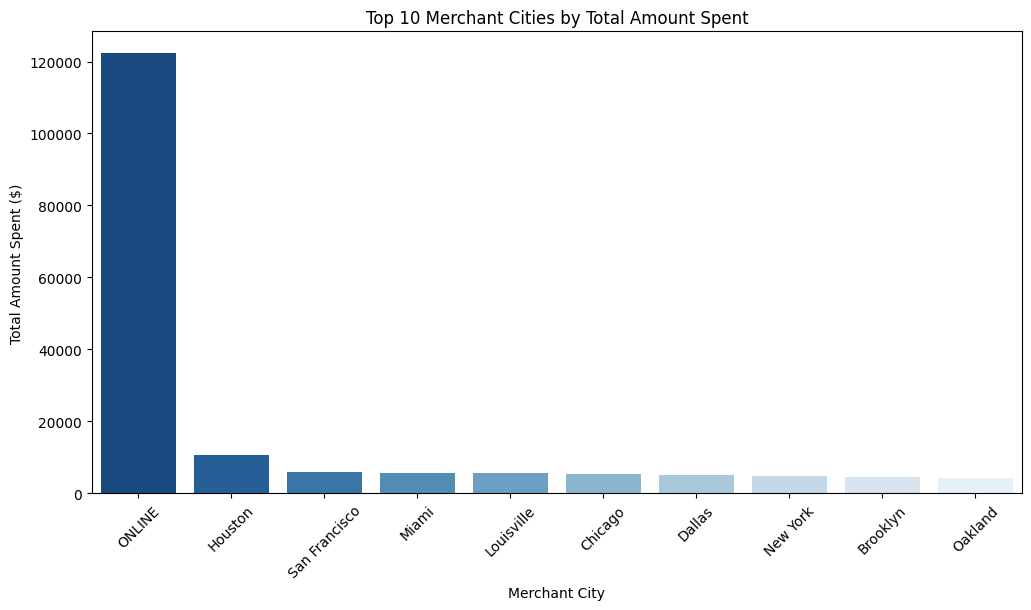

In [ ]:
# Create a DataFrame with both total transactions and total amount spent
city_stats = df.groupby('merchant_city').agg(
    total_transactions=('merchant_city', 'count'),
    total_spent=('amount', 'sum')
).sort_values(by='total_spent', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=city_stats.index, y=city_stats['total_spent'], palette="Blues_r")
plt.xticks(rotation=45)
plt.title("Top 10 Merchant Cities by Total Amount Spent")
plt.xlabel("Merchant City")
plt.ylabel("Total Amount Spent ($)")
plt.show()

In [ ]:
df['date'] = pd.to_datetime(df['timestamp'])  # Convert to datetime
df = df.sort_values(by=['client_id', 'timestamp'])  # Sort by client & time

# Compute time difference between consecutive transactions for each client
df['time_diff'] = df.groupby('client_id')['timestamp'].diff().dt.total_seconds() / 3600  # Convert to hours

# Find anomalies where transactions occur in different cities within a short period
df['location_change'] = df['merchant_city'] != df.groupby('client_id')['merchant_city'].shift(1)

# Flag anomalies where a location change happens within 2 hours
df['suspicious_travel'] = (df['location_change']) & (df['time_diff'] < 2)

# Display suspicious cases
suspicious_customers = df[df['suspicious_travel']]
print(suspicious_customers[['client_id', 'merchant_city', 'timestamp', 'time_diff']])

       client_id merchant_city           timestamp  time_diff
11584          0    Springvale 2010-01-04 13:19:00   0.266667
11850          0   Scarborough 2010-01-04 14:39:00   1.333333
15002          0        ONLINE 2010-01-05 14:02:00   1.883333
15377          0   Steep Falls 2010-01-05 15:49:00   1.783333
1575           1        ONLINE 2010-01-01 12:18:00   0.116667
...          ...           ...                 ...        ...
4437        1996         Alvin 2010-01-02 10:37:00   0.766667
17125       1996       Bacliff 2010-01-06 08:47:00   1.016667
15346       1997       Hopkins 2010-01-05 15:36:00   1.033333
18504       1997    Clear Lake 2010-01-06 14:39:00   1.433333
7105        1998        ONLINE 2010-01-03 08:03:00   1.000000

[2612 rows x 4 columns]


<ipython-input-32-65a897e3bff2>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['timestamp'])  # Convert to datetime


In [ ]:
df['amount'] = df['amount'].astype(float)  # Convert 'amount' to numeric

# Calculate each customer's average and standard deviation of spending
client_stats = df.groupby('client_id')['amount'].agg(['mean', 'std']).reset_index()
client_stats.columns = ['client_id', 'avg_spend', 'spending_std']

# Merge back to original data
df = df.merge(client_stats, on='client_id', how='left')

# Define an anomaly: transaction > (avg + 3 * std deviation)
df['is_anomaly'] = df['amount'] > (df['avg_spend'] + 3 * df['spending_std'])

# Show anomalies
anomalies = df[df['is_anomaly']]
print(anomalies[['client_id', 'amount', 'avg_spend', 'spending_std']])

       client_id  amount  avg_spend  spending_std
25             1   64.67  17.216250     13.329487
71             4  250.03  46.977273     56.925110
306           37  256.35  33.878214     71.789682
327           38  216.30  35.664828     39.545380
371           39  413.68  65.101250     78.201448
...          ...     ...        ...           ...
19682       1976  492.52  57.514762    101.451203
19716       1977  459.00  42.540000    107.951899
19731       1979  372.28  39.648947     99.074337
19784       1985   85.23  13.752059     20.432232
19820       1986  415.22  64.280625    101.434790

[203 rows x 4 columns]


In [ ]:
#export df_merged into csv file
df_merged.to_csv('df_merged.csv', index=False)